In [2]:
from astropy.io import fits
from astropy.table import Table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


print('coolio!')

coolio!


In [3]:
def RawFileToPandas(file_name):
    
    hdul = fits.open(file_name)
    hdu1 = hdul[1]
    data = hdu1.data
    table = Table(data)

    l1 = []
    for name in table.colnames:
        if len(table[name].shape)<=1:
            l1.append(name)
    unidim = table[l1]

    df = unidim.to_pandas()

    hdul.close()
    
    return df

In [4]:
df_info = RawFileToPandas('../data/galSpecInfo-dr8.fits')
df_extra = RawFileToPandas('../data/galSpecExtra-dr8.fits')
df_line = RawFileToPandas('../data/galSpecLine-dr8.fits')

print(df_info.shape)
print(df_extra.shape)
print(df_line.shape)

(1843200, 22)
(1843200, 45)
(1843200, 241)


In [5]:
ids_match = (
    df_info['SPECOBJID'].equals(df_extra['SPECOBJID'])
    and df_info['SPECOBJID'].equals(df_line['SPECOBJID'])
)
print(ids_match)

True


In [6]:
dic1 = {
    'targettype': df_info['TARGETTYPE'].str.strip(),
    'redshift' : df_info['Z'],
    'reliable' : df_info['RELIABLE'],
    'log_mass' : df_extra['LGM_TOT_P50'],
    'log_sfr' : df_extra['SFR_TOT_P50'],
    'log_ssfr' : df_extra['SPECSFR_TOT_P50'],
    'bpt_class' : df_extra['BPTCLASS'],
    'ha_flux' : df_line['H_ALPHA_FLUX'],
    'ha_err' : df_line['H_ALPHA_FLUX_ERR'],
    'hb_flux' : df_line['H_BETA_FLUX'],
    'hb_err' : df_line['H_BETA_FLUX_ERR'],
    'oiii_flux' : df_line['OIII_5007_FLUX'],
    'oiii_err' : df_line['OIII_5007_FLUX_ERR'],
    'nii_flux' : df_line['NII_6584_FLUX'],
    'nii_err' : df_line['NII_6584_FLUX_ERR'],
}

master = pd.DataFrame(dic1)
print(master.shape)

(1843200, 15)


In [7]:
def CleanData_and_RedshiftFilter(t1, z1, z2):
    a = t1['reliable'] == 1
    b = t1['targettype'] == 'GALAXY'
    c = t1['redshift'] >= z1
    d = t1['redshift'] <= z2
    e = t1['log_mass'] > -9990
    f = t1['log_sfr'] > -9990
    g = t1['log_ssfr'] > -9990

    smpl = t1[ a & b & c & d & e & f & g]
    
    return smpl

def CleanForAGN(smp):
    a = smp['bpt_class'] == 4
    b = smp['ha_flux']/smp['ha_err'] >= 3
    c = smp['hb_flux']/smp['hb_err'] >= 3
    d = smp['oiii_flux']/smp['oiii_err'] >= 3
    e = smp['nii_flux']/smp['nii_err'] >=3

    agnn = smp[ a & b & c & d & e].copy()

    return agnn

In [8]:
sample = CleanData_and_RedshiftFilter(master, 0.02, 0.2)
agn = CleanForAGN(sample)
#print(agn.head())

In [9]:
sample_x = np.log10(sample["nii_flux"] / sample["ha_flux"])
sample_y = np.log10(sample["oiii_flux"] / sample["hb_flux"])

agn_x = np.log10(agn["nii_flux"] / agn["ha_flux"])
agn_y = np.log10(agn["oiii_flux"] / agn["hb_flux"])

sample_finite = np.isfinite(sample_x) & np.isfinite(sample_y)
agn_finite = np.isfinite(agn_x) & np.isfinite(agn_y)

sample_x = sample_x[sample_finite]
sample_y = sample_y[sample_finite]

agn_x = agn_x[agn_finite]
agn_y = agn_y[agn_finite]

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


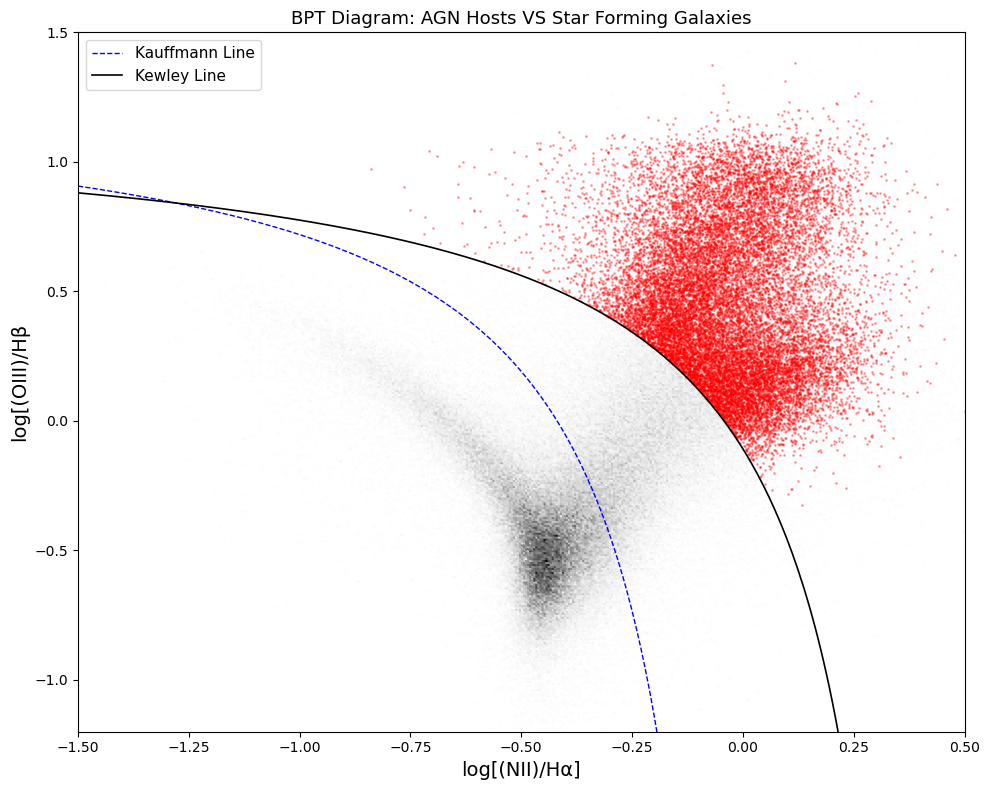

In [10]:
fig1, ax1 = plt.subplots(figsize = (10,8))

ax1.hexbin(sample_x, sample_y, gridsize = 3000, cmap = 'Greys', mincnt = 1)
ax1.scatter(agn_x, agn_y, color = 'red', alpha = 0.3, s = 1, zorder = 2)

x_kewley = np.linspace(-1.5, 0.45, 300)
y_kewley = (0.61 / (x_kewley - 0.47)) + 1.19

x_kauffmann = np.linspace(-1.5, 0.00, 300)
y_kauffmann = (0.61 / (x_kauffmann - 0.05)) + 1.3

ax1.plot(x_kauffmann, y_kauffmann, color = 'blue', linewidth = 1, linestyle = '--', label = 'Kauffmann Line')
ax1.plot(x_kewley, y_kewley, color = 'black', linewidth = 1.2, linestyle = '-', label = 'Kewley Line')

ax1.set_xlabel('log[(NII)/Hα]', fontsize = 14)
ax1.set_ylabel('log[(OIII)/Hβ', fontsize = 14)
ax1.set_xlim(-1.5, 0.5)
ax1.set_ylim(-1.2, 1.5)

ax1.legend(fontsize = 11)
ax1.set_title('BPT Diagram: AGN Hosts VS Star Forming Galaxies', fontsize = 13)

fig1.savefig('../figures/BPT.pdf', dpi=300)

plt.tight_layout()
plt.show()

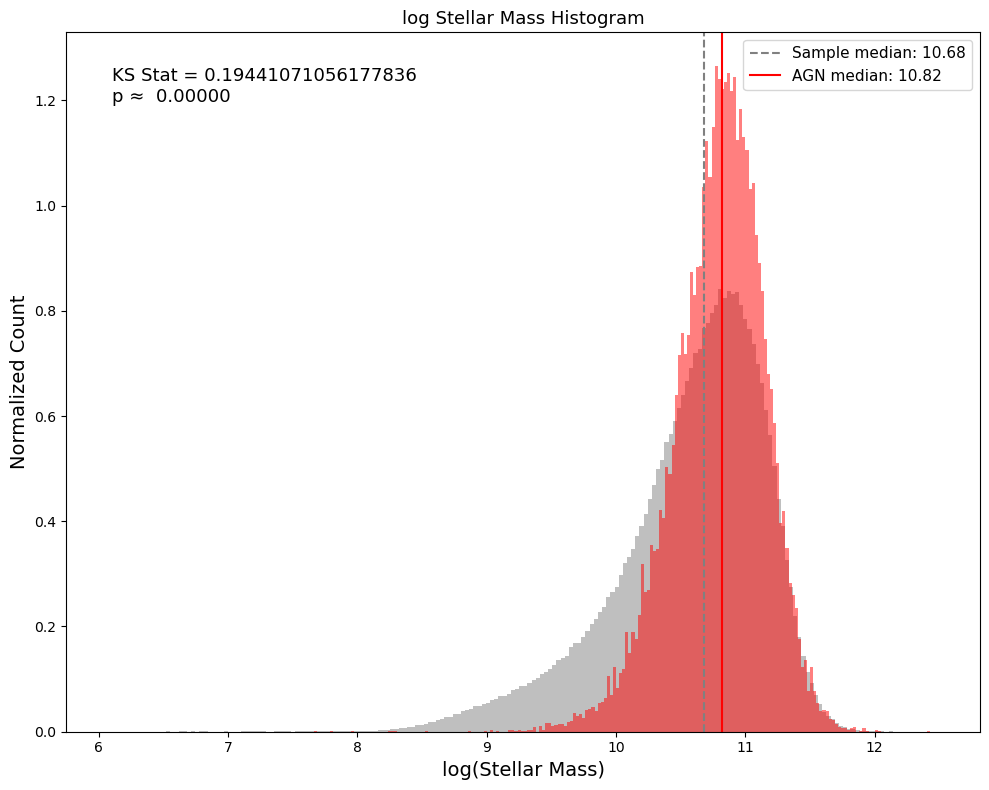

In [11]:
ks2, p2 = stats.ks_2samp(sample['log_mass'], agn['log_mass'])

fig2, ax2 = plt.subplots(figsize = (10,8))

ax2.hist(sample['log_mass'], bins = 200, color = 'Grey', alpha = 0.5, density = True)
ax2.hist(agn['log_mass'], bins = 200, color = 'red', alpha = 0.5, density = True)
ax2.set_xlabel('log(Stellar Mass)', fontsize = 14)
ax2.set_ylabel('Normalized Count', fontsize = 14)
ax2.axvline(sample['log_mass'].median(), color = 'grey', linestyle='--', linewidth=1.5, label=f'Sample median: {sample["log_mass"].median():.2f}')
ax2.axvline(agn['log_mass'].median(), color='red', linestyle='-', linewidth=1.5, label=f'AGN median: {agn["log_mass"].median():.2f}')
ax2.legend(fontsize = 11)
ax2.set_title('log Stellar Mass Histogram', fontsize = 13)

ax2.text(0.05, 0.95, f'KS Stat = {ks2} \np ≈ {p2: .5f}', transform = ax2.transAxes, fontsize = 13, verticalalignment = 'top')

fig2.savefig('../figures/Mass histogram.pdf', dpi=300)

plt.tight_layout()
plt.show()

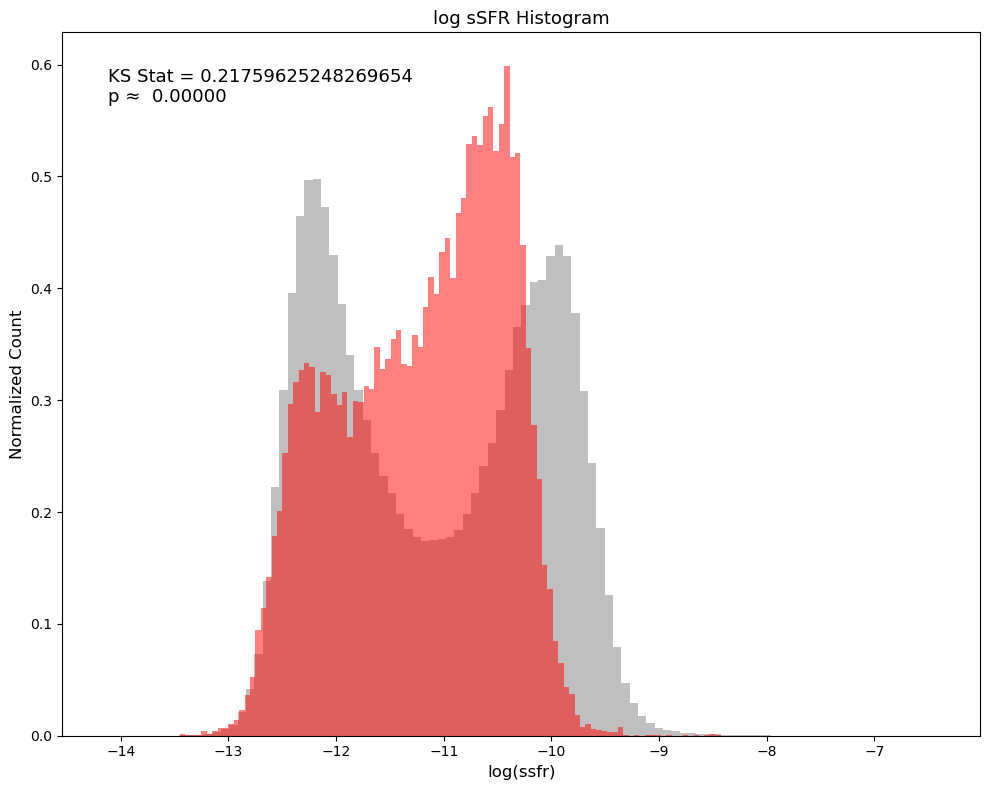

In [12]:
ks, p = stats.ks_2samp(sample['log_ssfr'], agn['log_ssfr'])

fig3, ax3 = plt.subplots(figsize = (10,8))
ax3.hist(sample['log_ssfr'], bins = 100, color = 'Grey', alpha = 0.5, density = True)
ax3.hist(agn['log_ssfr'], bins = 100, color = 'Red', alpha = 0.5, density = True)
ax3.set_xlabel('log(ssfr)', fontsize = 12)
ax3.set_ylabel('Normalized Count', fontsize = 12)
ax3.set_title('log sSFR Histogram', fontsize = 13)

ax3.text(0.05, 0.95, f'KS Stat = {ks} \np ≈ {p: .5f}', transform = ax3.transAxes, fontsize = 13, verticalalignment = 'top')

fig3.savefig('../figures/sSFR histogram.pdf', dpi=300)

plt.tight_layout()
plt.show()


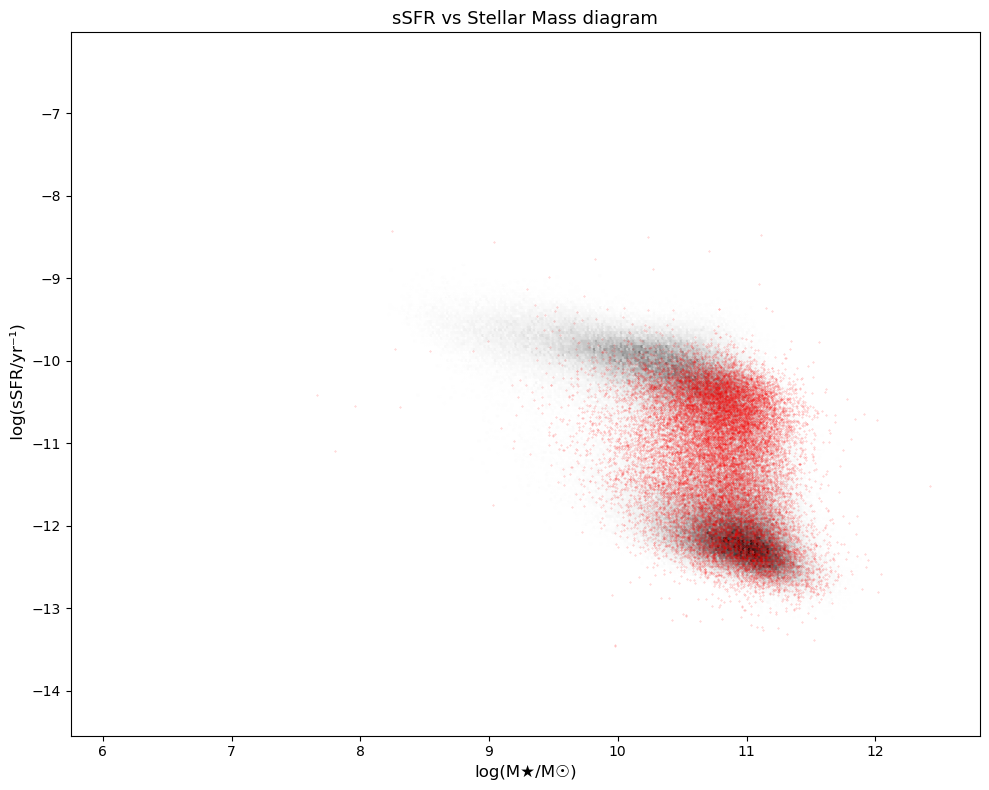

In [13]:
fig4, ax4 = plt.subplots(figsize = (10,8))


ax4.hexbin(sample['log_mass'], sample['log_ssfr'], gridsize = 400, cmap = 'Greys', mincnt = 1)
ax4.scatter(agn['log_mass'], agn['log_ssfr'], color = 'red', alpha = 0.3, zorder = 3, s = 0.1)
ax4.set_xlabel('log(M★/M☉)', fontsize=12)
ax4.set_ylabel(' log(sSFR/yr⁻¹)', fontsize=12)
ax4.set_title('sSFR vs Stellar Mass diagram', fontsize = 13)

fig4.savefig('../figures/sSFR vs Mass.pdf', dpi=300)

plt.tight_layout()
plt.show()

In [15]:
edges  = np.linspace(9, 12, 21)
centre = (edges[:-1] + edges[1:]) / 2

sample_massbin = pd.cut(sample['log_mass'], bins = edges)
agn_massbin = pd.cut(agn['log_mass'], bins = edges)

count_sample = sample_massbin.value_counts(sort = False)
count_agn = agn_massbin.value_counts(sort = False)

frac = (count_agn/count_sample)*100

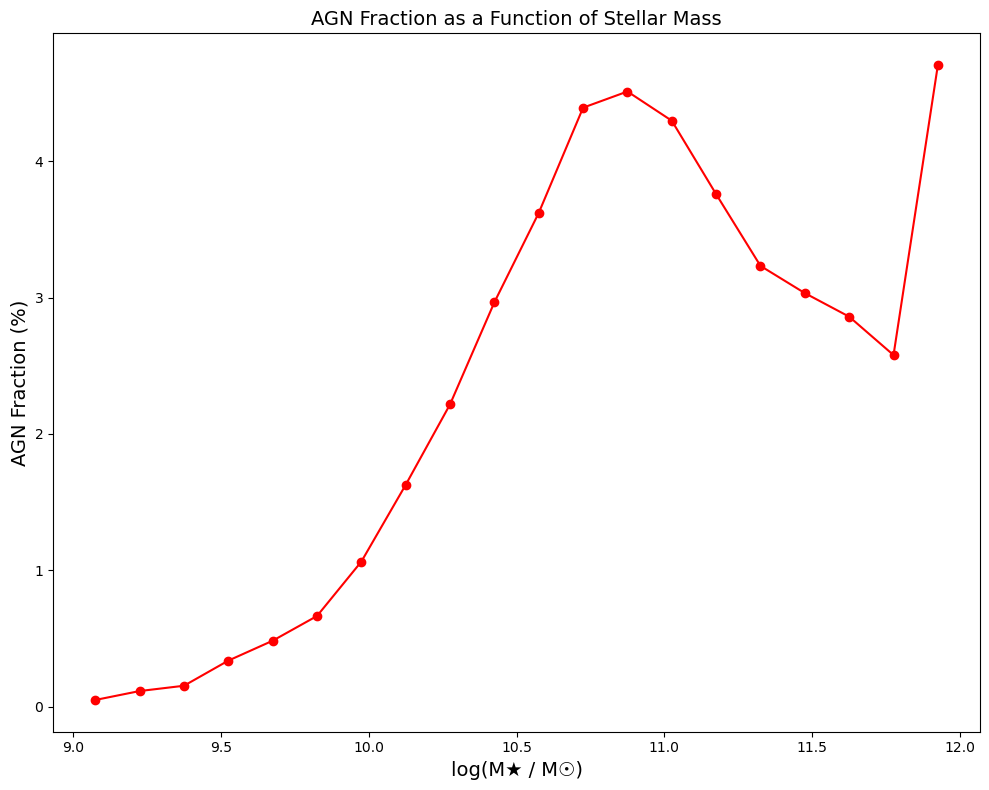

In [16]:
fig5, ax5 = plt.subplots(figsize = (10,8))

ax5.plot(centre, frac, color = 'red', linewidth = 1.5, marker = 'o')
ax5.set_xlabel("log(M★ / M☉)", fontsize=14)
ax5.set_ylabel("AGN Fraction (%)", fontsize=14)
ax5.set_title("AGN Fraction as a Function of Stellar Mass", fontsize=14)

fig5.savefig('../figures/AGN fraction.pdf', dpi=300)

plt.tight_layout()
plt.show()

In [18]:
sampleQ = sample.groupby(sample_massbin, observed = False)["log_sfr"].quantile([0.16, 0.50, 0.84])
agnQ = agn.groupby(agn_massbin, observed = False)["log_sfr"].quantile([0.16, 0.50, 0.84])

sampleQ = sampleQ.unstack()
agnQ = agnQ.unstack()

smp_med = sampleQ[0.50]
smp_low = sampleQ[0.16]
smp_high = sampleQ[0.84]

agn_med = agnQ[0.50]
agn_low = agnQ[0.16]
agn_high = agnQ[0.84]


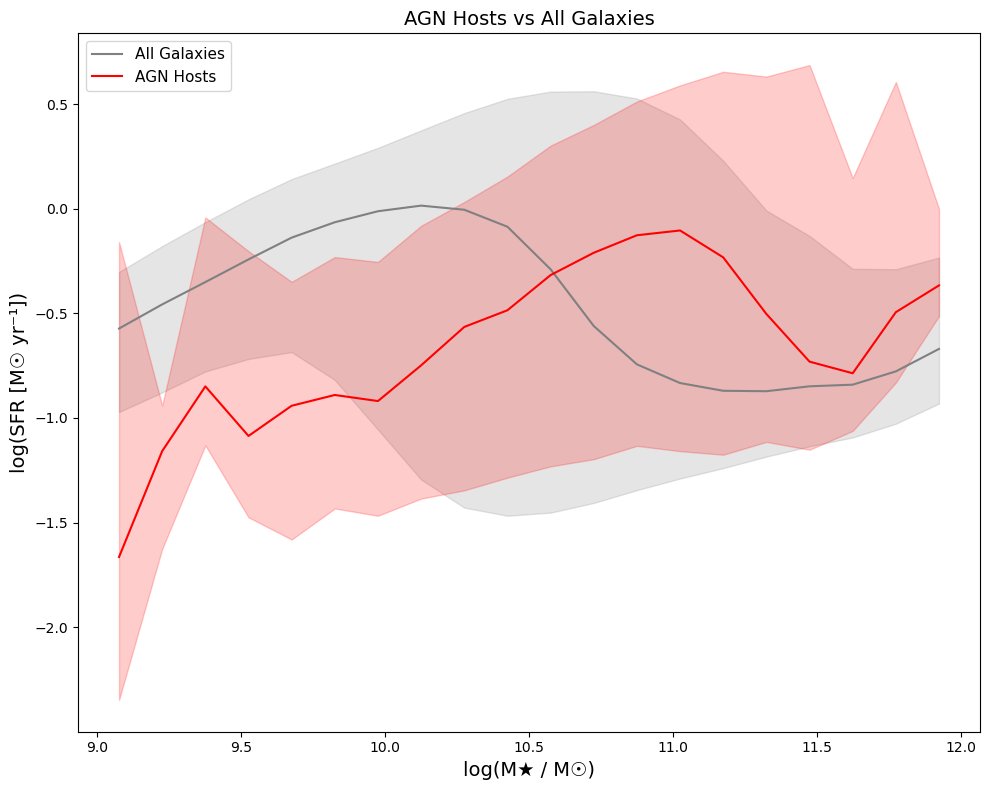

In [19]:
fig6, ax6 = plt.subplots(figsize = (10,8))
ax6.plot(centre, smp_med, color = 'grey', linewidth = 1.5, label = 'All Galaxies')
ax6.fill_between(centre, smp_low, smp_high, alpha = 0.2, color = 'grey')

ax6.plot(centre, agn_med, color = 'red', linewidth = 1.5, label = 'AGN Hosts')
ax6.fill_between(centre, agn_low, agn_high, alpha = 0.2, color = 'red')

ax6.set_xlabel("log(M★ / M☉)", fontsize=14)
ax6.set_ylabel("log(SFR [M☉ yr⁻¹])", fontsize=14)

ax6.set_title('AGN Hosts vs All Galaxies', fontsize = 14)
ax6.legend(fontsize = 11)

fig6.savefig('../figures/AGN Host vs All Galaxies.pdf', dpi=300)

plt.tight_layout()
plt.show()

Non-quiescent sample: 377,847 galaxies


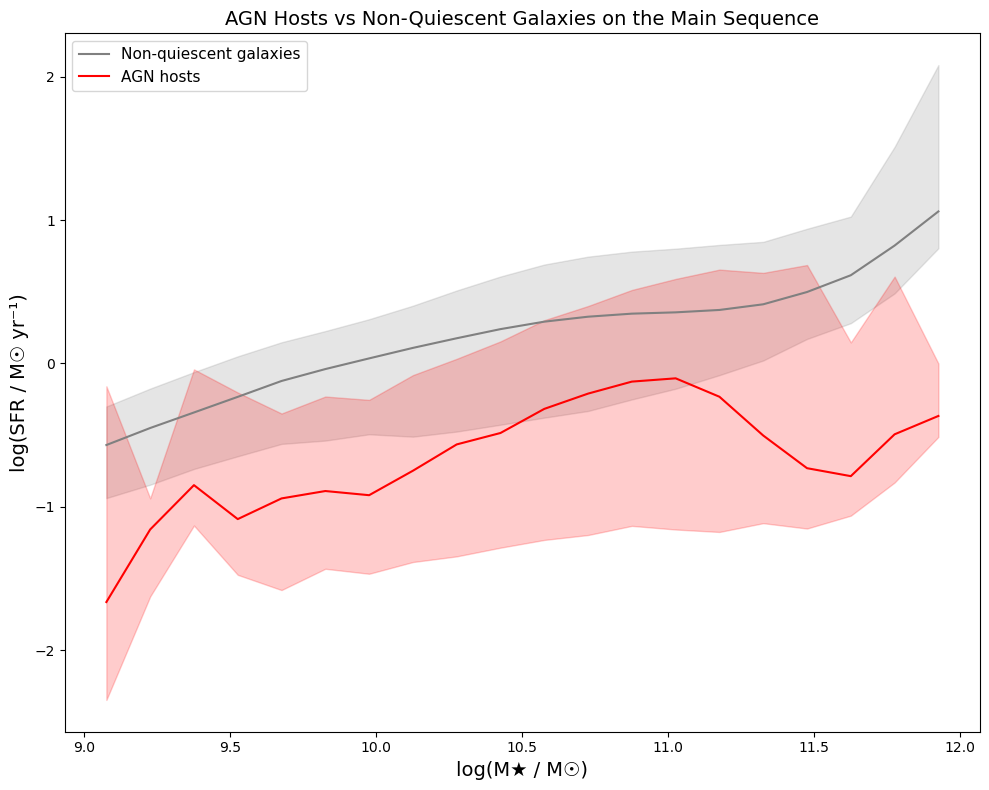

In [20]:
non_quiescents = sample[sample["log_ssfr"] > -11.5].copy()
print(f'Non-quiescent sample: {len(non_quiescents):,} galaxies')

nq_massbin = pd.cut(non_quiescents["log_mass"], bins=edges)

nqQ = non_quiescents.groupby(nq_massbin, observed=False)["log_sfr"].quantile([0.16, 0.50, 0.84])
nqQ = nqQ.unstack()

nq_median = nqQ[0.50]
nq_low = nqQ[0.16]
nq_high = nqQ[0.84]

fig7, ax7 = plt.subplots(figsize=(10, 8))

ax7.plot(centre, nq_median, color="grey", linewidth=1.5, label="Non-quiescent galaxies")
ax7.fill_between(centre, nq_low, nq_high, alpha=0.2, color="grey")

ax7.plot(centre, agn_med, color="red", linewidth=1.5, label="AGN hosts")
ax7.fill_between(centre, agn_low, agn_high, alpha=0.2, color="red")

ax7.set_xlabel("log(M★ / M☉)", fontsize=14)
ax7.set_ylabel("log(SFR / M☉ yr⁻¹)", fontsize=14)
ax7.set_title("AGN Hosts vs Non-Quiescent Galaxies on the Main Sequence", fontsize=14)

ax7.legend(fontsize=11)

fig7.savefig('../figures/AGN Host vs Star-forming-only Galaxies.pdf', dpi=300)

plt.tight_layout()
plt.show()

In [21]:
print('Coolio')

Coolio
